# Traffic Dashboard

/tmp/ipykernel_2284/334421117.py:48: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




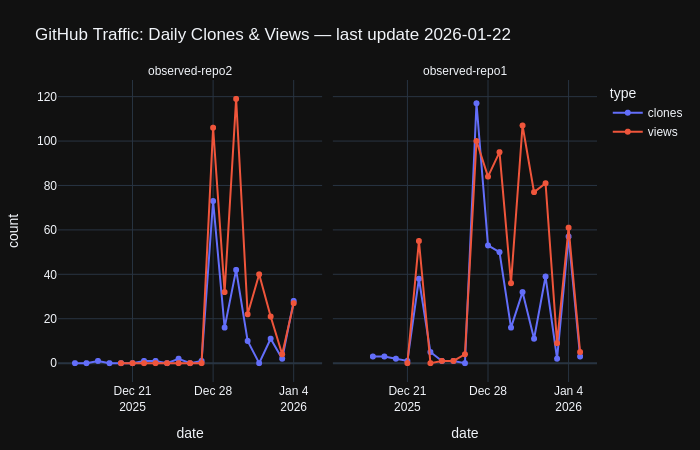

In [1]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
import glob
import os
from datetime import datetime

# Set renderer to PNG so it's visible on GitHub's file preview
pio.renderers.default = "png"

# 1. Load data
path = 'data' 
all_files = glob.glob(os.path.join(path, "*.csv"))

if not all_files:
    print("No CSV files found in /data directory!")
else:
    li = [pd.read_csv(f) for f in all_files]
    df = pd.concat(li, axis=0, ignore_index=True)

    # 2. Data Cleaning
    df_daily = df[~df['date'].str.contains('~')].copy()
    df_daily['date'] = pd.to_datetime(df_daily['date'])
    df_daily = df_daily.sort_values('date')

    # 3. Visualization
    fig = px.line(df_daily, 
                  x='date', 
                  y='count', 
                  color='type', 
                  facet_col='repository', 
                  facet_col_wrap=2,
                  title=f'GitHub Traffic: Daily Clones & Views — last update {datetime.now():%Y-%m-%d}',
                  template='plotly_dark', # Looks great in the Observatory!
                  markers=True)

    # This removes "repository=" AND everything before the slash
    fig.for_each_annotation(lambda a: a.update(text=a.text.split("/")[-1]))

    fig.update_layout(
    hovermode="x unified", 
    height=450,          # Reduced from 800
    margin=dict(t=80, b=50, l=50, r=50) # Tighter margins make the plots feel wider
    )

    # Save the figure as a high-res PNG for the README
    # A 2:1 or 2.5:1 ratio is usually best for side-by-side charts
    fig.write_image("dashboard_preview.png", width=1200, height=500, scale=2)
    
    fig.show()